In [2]:
#Kaggleの『AI Learner Tech: EV Prices 2026 (EDA & ML)』
#(https://www.kaggle.com/datasets/ailearner-researchlab/ai-learner-tech-ev-prices-and-specs-2026?select=AI_Learner_EV_Dataset_Pro.csv)
#を使用して欧州で販売されるEV車のコスパTop 10と割高Top 10モデルを予測した。

# =========================
# ① ライブラリ
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

# =========================
# ② データ読み込み
# =========================
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')


In [3]:
# =========================
# ③ 外れ値除去（IQR）
# =========================
cols = ["PriceEuro", "TopSpeed_KmH", "Range_Km", "AccelSec"]  #対象の列を指定

def remove_outliers_iqr(df, cols):  #DataFrame（df）と対象列（cols）を受け取る関数を定義
    df_clean = df.copy()  #元データを壊さないためコピーを作成
    for col in cols:
        #四分位数を計算
        Q1 = df_clean[col].quantile(0.25) #Q1（第1四分位数）：小さい順に並べたときの下から25%の位置
        Q3 = df_clean[col].quantile(0.75) #Q3（第3四分位数）：下から75%の位置
        IQR = Q3 - Q1 #IQRを計算
        #外れ値の範囲を決定:この範囲を外れると「外れ値」と認定
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        #外れ値を削除:下限以上、上限以下
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean #最終結果を返す

df = remove_outliers_iqr(df, cols)

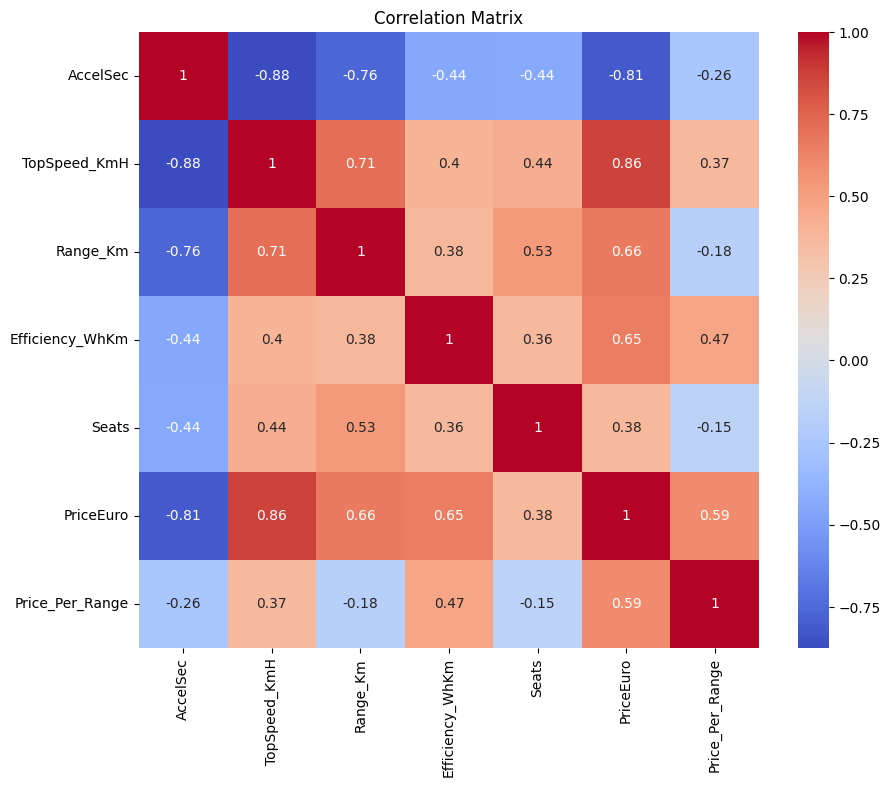

In [4]:
# =========================
# ④ 可視化（相関関係確認）
#Heatmapの表示結果からはAccelSec, TopSpeed_KmHとPriceEuroの相関性が高いように見える
# =========================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [5]:
# =========================
# ⑤ 特徴量エンジニアリング
#欧州消費者がEV車に求めるものとしては走行距離や効率性が高いと思わるため
#Perfomance_IndexとEfficiency_Scoreとして下記条件を設定
# =========================
df["Performance_Index"] = df["Range_Km"] / df["PriceEuro"] #「航続距離のコスパ」を評価
df["Efficiency_Score"] = 1 / df["Efficiency_WhKm"]  #「効率が良いほど値が大きくなるように変換」

In [8]:
# ===== 特徴量 =====
df["Performance_Index"] = df["Range_Km"] / df["PriceEuro"]
df["Efficiency_Score"] = 1 / df["Efficiency_WhKm"]

# ===== 目的変数 =====
y = df["PriceEuro"]

# ===== 特徴量セット =====
features = [
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Performance_Index",
    "Efficiency_Score"
]

X = df[features]

# ===== モデル =====
from sklearn.linear_model import Ridge
import numpy as np

model = Ridge()
model.fit(X, y)

# ===== 重要度 =====
importance = np.abs(model.coef_)

weights = dict(zip(features, importance))

# 正規化
total = sum(weights.values())
for k in weights:
    weights[k] /= total

print(weights)

{'Range_Km': np.float64(0.0005508439797894153), 'TopSpeed_KmH': np.float64(0.20193756673146515), 'AccelSec': np.float64(0.429851235276922), 'Efficiency_WhKm': np.float64(0.12710578552904742), 'Performance_Index': np.float64(0.23671669487610672), 'Efficiency_Score': np.float64(0.0038378736066691536)}


In [11]:
#AIで「欧州消費者がEV車に求めるもの」と検索すると1回の充電で走行できる総距離距離、キロあたりの効率性、価格などとなっているので
#以下の項目をPopularity_scoreとして重み付けをした：

df["Popularity_Score"] = (
    0.30 * (df["Range_Km"] / df["Range_Km"].max()) +
    0.30 * (df["Price_Per_Range"] / df["Price_Per_Range"].max()) +
    0.30 * (df["Efficiency_WhKm"] / df["Efficiency_WhKm"].max()) +
    0.10 * (df["PriceEuro"] / df["PriceEuro"].max())
)

In [12]:
# =========================
# ⑦ 特徴量選択
# =========================

#モデルに入力する説明変数（X）を定義
features = [
    "TopSpeed_KmH",
    "Range_Km",
    "AccelSec",
    "Price_Per_Range",
    "Performance_Index"
]

X = df[features]  #入力データ（X）
y = np.log1p(df["PriceEuro"]) #目的変数（y）

In [13]:
# =========================
# ⑧ 標準化（SVR用）
# =========================
#SVR（サポートベクター回帰）用にデータのスケールを揃える処理
#できるだけ誤差を小さくしつつ、シンプルな関数で予測する回帰モデル
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #fit（学習）:各列の平均と標準偏差を計算 + transform（変換）:スケール変換

In [14]:
# =========================
# ⑨ モデル定義
# =========================

#どのモデルで学習するかをまとめて定義して比較
models = {
    "Ridge": Ridge(alpha=1.0),  #Ridge（リッジ回帰）複雑になりすぎないよう制限
    "SVR": SVR(kernel="rbf", C=10), #サポートベクター回帰（Support Vector Regression）
    "LightGBM": LGBMRegressor(  #LightGBM
        n_estimators=100, #「木」の数
        max_depth=3,  #木の深さ
        learning_rate=0.05  #学習の慎重さ
    )
}

In [15]:
# =========================
# ⑩ CV(Cross Validation)評価
# =========================

#3つのモデル（Ridge / SVR / LightGBM）のうち一番適したモデルを順番に評価
print("=== Cross Validation ===")
for name, model in models.items():

    if name == "SVR":
        scores = cross_val_score(model, X_scaled, y,  #クロスバリデーションでモデルを評価
                                 cv=5,  #Cross Validation=5回テストして平均を取る
                                 scoring="neg_root_mean_squared_error") #RMSE:予測のズレの大きさ
    else:
        scores = cross_val_score(model, X, y,
                                 cv=5,
                                 scoring="neg_root_mean_squared_error")

    print(f"{name} RMSE:", -scores.mean())

=== Cross Validation ===
Ridge RMSE: 0.08656509698538573
SVR RMSE: 0.08534734103199607
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000240 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 107
[LightGBM] [Info] Number of data points in the train set: 73, number of used features: 5
[LightGBM] [Info] Start training from score 10.670894
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [16]:
# =========================
# ⑪ 最終モデル（Ridge）
# =========================

#CV評価の結果LightGBM RMSE: 0.1699515153678878, Ridge RMSE: 0.08656509698538573SVR RMSE: 0.08534734103199607
#のためRMSEが一番低いRidgeがベストなモデルと判定
#データを 学習用80% / 検証用20% に分ける
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train) #特徴量 → 価格（log） の関係を学習

pred = model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(
    np.expm1(y_valid),
    np.expm1(pred)
))

print("\nFinal RMSE:", rmse)


Final RMSE: 3613.005382831805


In [17]:
# =========================
# ⑫ 全データで価格予測
# =========================
df["PredictedPrice"] = np.expm1(model.predict(X))

In [18]:
# =========================
# ⑬ コスパ指標
# =========================
df["Value_Score"] = df["Popularity_Score"] / df["PredictedPrice"]

In [21]:
# =========================
# ⑭ 結果表示
# =========================

# ① Residualを作る
df["Residual"] = df["PriceEuro"] - df["PredictedPrice"]

result = df[[
    "Brand",
    "Model",
    "PriceEuro",
    "PredictedPrice",
    "Range_Km",
    "Price_Per_Range",
    "Residual"   # ←これに変更
]].sort_values("Residual")

print("\n=== コスパ最強 TOP10（割安） ===")
print(result.head(10))

print("\n=== 割高ワースト10 ===")
print(result.tail(10))


=== コスパ最強 TOP10（割安） ===
          Brand                          Model  PriceEuro  PredictedPrice  \
36       Lucid                            Air      105000   126838.032777   
41       Smart                EQ fortwo cabrio      24565    32803.464878   
1        Tesla           Cybertruck Dual Motor      55000    61548.426373   
95       Smart                 EQ fortwo coupe      21387    27255.390723   
50       Smart                     EQ forfour       22030    27881.777409   
5        Tesla              Model S Long Range      79990    85572.858406   
26  Volkswagen                      ID.3 Pro S      40936    46197.419903   
84       CUPRA                        el-Born       45000    50085.742510   
52         BMW                             i4       65000    69825.175747   
9        Tesla   Model 3 Long Range Dual Motor      55480    59820.371793   

    Range_Km  Price_Per_Range      Residual  
36       610           172.13 -21838.032777  
41        95           258.58  -823

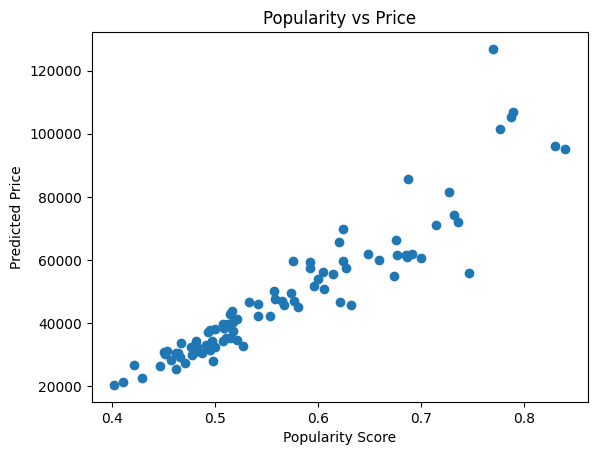

In [22]:
# =========================
# ⑮ 可視化① 人気 vs 価格
# =========================
plt.scatter(df["Popularity_Score"], df["PredictedPrice"])
plt.xlabel("Popularity Score")
plt.ylabel("Predicted Price")
plt.title("Popularity vs Price")
plt.show()

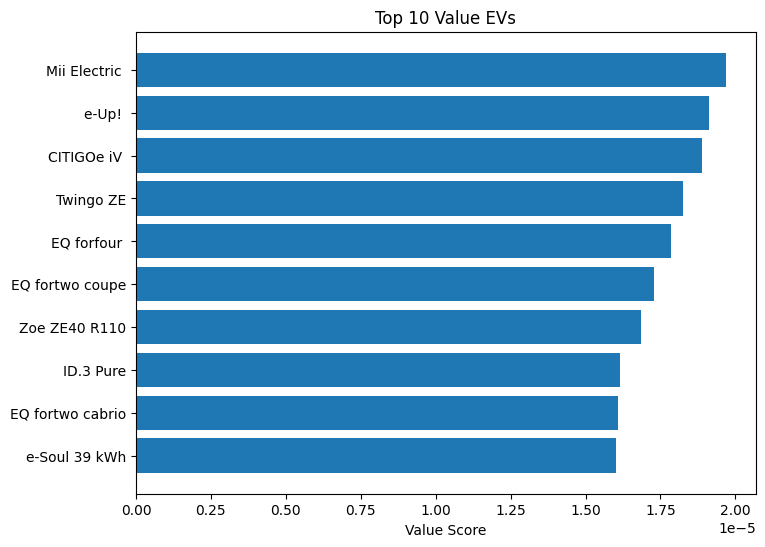

In [23]:
# =========================
# ⑰ 可視化③ コスパTOP10
# =========================
value_top10 = df.sort_values("Value_Score", ascending=False).head(10)

plt.figure(figsize=(8,6))
plt.barh(value_top10["Model"], value_top10["Value_Score"])
plt.title("Top 10 Value EVs")
plt.xlabel("Value Score")
plt.gca().invert_yaxis()
plt.show()

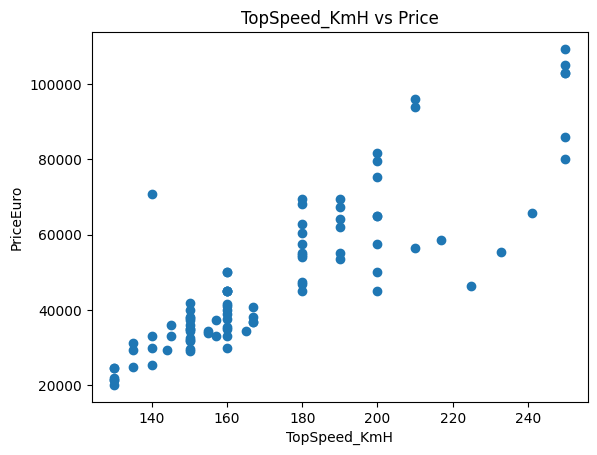

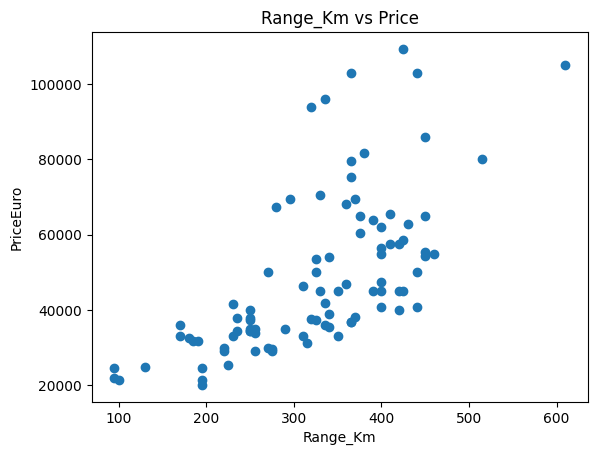

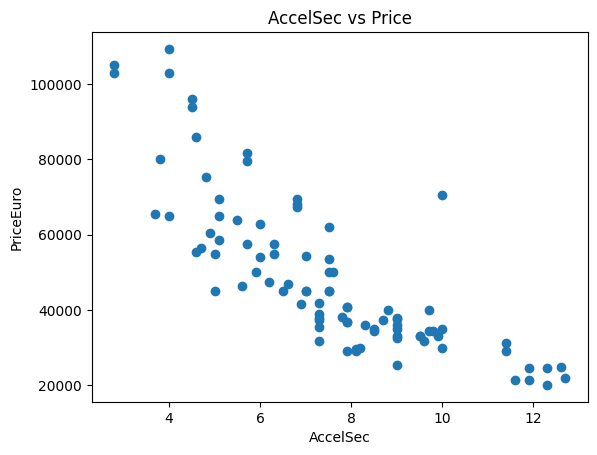

In [24]:
# =========================
# ⑱ 可視化④ 価格 vs 性能
# =========================

features = ["TopSpeed_KmH", "Range_Km", "AccelSec"]

for col in features:
    plt.scatter(df[col], df["PriceEuro"])
    plt.xlabel(col)
    plt.ylabel("PriceEuro")
    plt.title(f"{col} vs Price")
    plt.show()

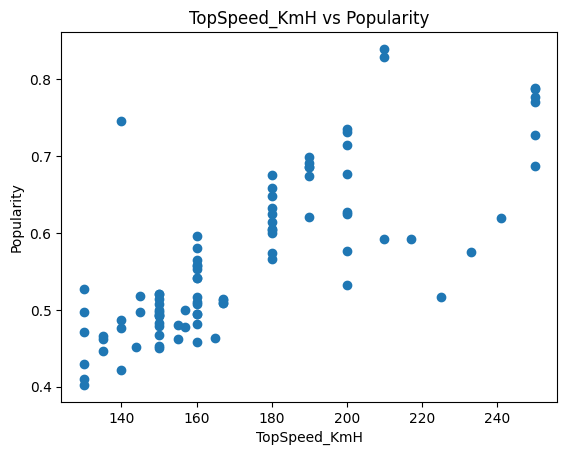

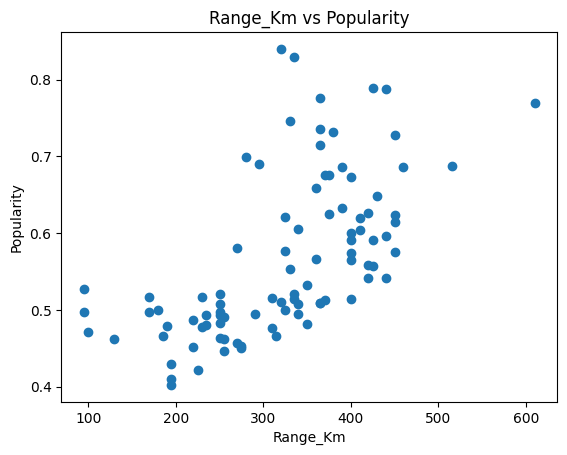

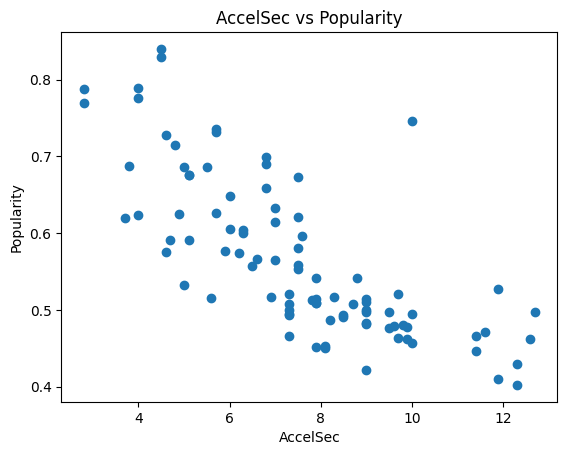

In [25]:
# =========================
# ⑲ 可視化⑤ 人気 vs 性能
# =========================

for col in features:
    plt.scatter(df[col], df["Popularity_Score"])
    plt.xlabel(col)
    plt.ylabel("Popularity")
    plt.title(f"{col} vs Popularity")
    plt.show()

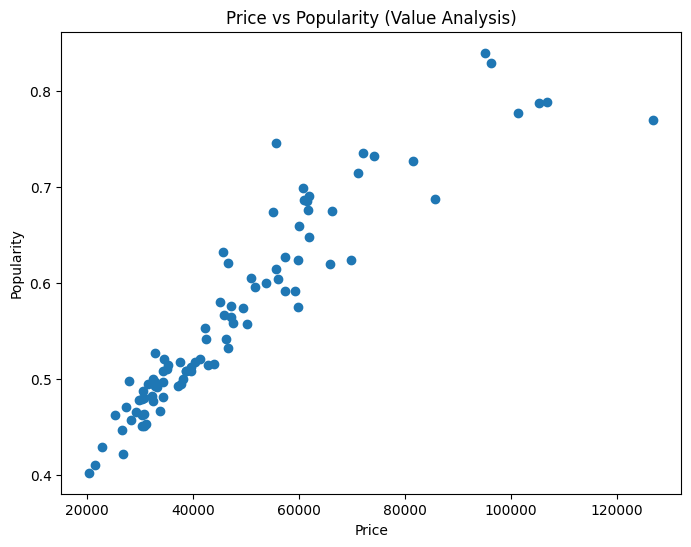

In [26]:
# =========================
# ⑳ 可視化⑥ コスパ
# =========================

plt.figure(figsize=(8,6))

plt.scatter(df["PredictedPrice"], df["Popularity_Score"])

plt.xlabel("Price")
plt.ylabel("Popularity")
plt.title("Price vs Popularity (Value Analysis)")

plt.show()

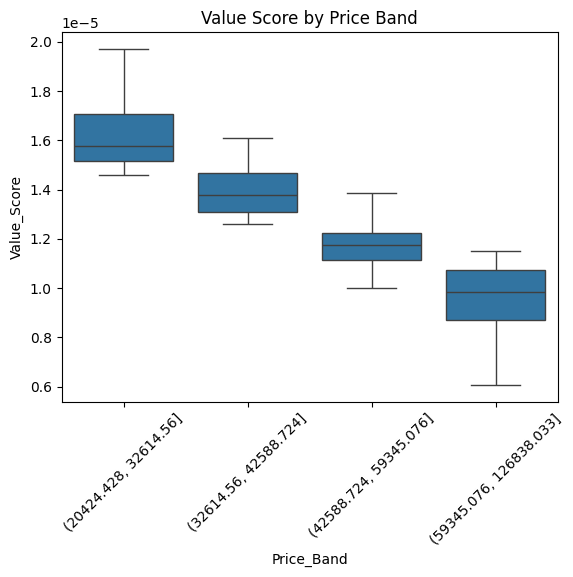

In [27]:
# =========================
# ㉑ 可視化⑦ 価格帯別コスパ
# =========================

df["Price_Band"] = pd.qcut(df["PredictedPrice"], 4)

sns.boxplot(x="Price_Band", y="Value_Score", data=df)
plt.xticks(rotation=45)
plt.title("Value Score by Price Band")
plt.show()

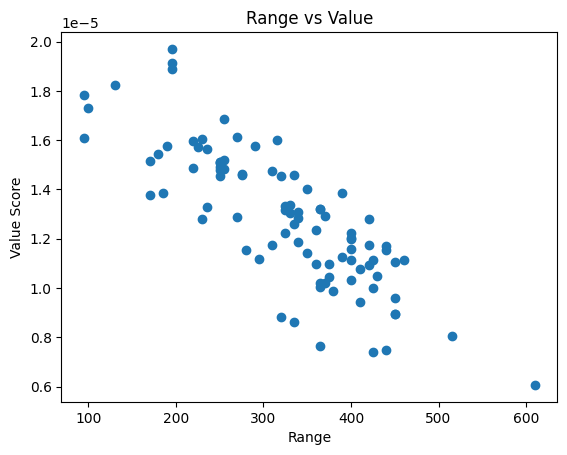

In [28]:
# =========================
# ㉒ 可視化⑧ コスパ vs 性能
# =========================

plt.scatter(df["Range_Km"], df["Value_Score"])
plt.xlabel("Range")
plt.ylabel("Value Score")
plt.title("Range vs Value")
plt.show()